In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
dia = pd.read_csv('/kaggle/input/playground-series-s5e12/train.csv')

In [4]:
dia.head()


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [5]:
dia.tail()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0
699999,699999,42,4,56,4.2,7.0,6.1,28.3,0.90,99,...,Female,Black,Graduate,Low,Former,Employed,0,0,0,1.0


In [6]:
dia.info()
dia.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

(700000, 26)

In [7]:
dia.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [8]:
dia.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
dia.describe(include= 'object')

,gender,ethnicity,education_level,income_level,smoking_status,employment_status
count,700000,700000,700000,700000,700000,700000
unique,3,5,4,5,3,4
top,Female,White,Highschool,Middle,Never,Employed
freq,363237,386153,344145,290557,494448,516170


In [10]:
dia.duplicated().sum()

np.int64(0)

In [11]:
dia.nunique()

id                                    700000
age                                       71
alcohol_consumption_per_week               9
physical_activity_minutes_per_week       565
diet_score                                99
sleep_hours_per_day                       69
screen_time_hours_per_day                151
bmi                                      231
waist_to_hip_ratio                        36
systolic_bp                               71
diastolic_bp                              54
heart_rate                                60
cholesterol_total                        154
hdl_cholesterol                           69
ldl_cholesterol                          151
triglycerides                            228
gender                                     3
ethnicity                                  5
education_level                            4
income_level                               5
smoking_status                             3
employment_status                          4
family_his

In [12]:
dob = [i for i in dia.columns if dia[i].dtype =='object']
        
print(dob)    
    

['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [13]:
for i in dob:
    print(f'{i}',dia[i].value_counts())

gender gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64
ethnicity ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64
education_level education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64
income_level income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64
smoking_status smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64
employment_status employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64


OUTLIER Detection and Removal

In [14]:
dia.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.500000,202072.738554,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00


HIGH STD will have high outlier possibilty

In [15]:
num_col = [i for i in dia.columns if dia[i].dtypes== int or dia[i].dtypes == float] 
print(num_col)

['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']


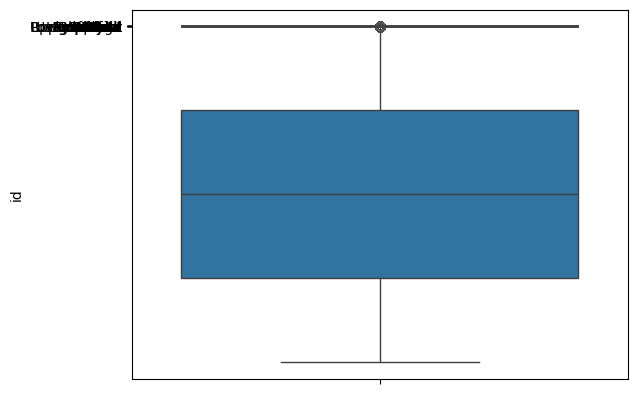

In [16]:
for i in dia.columns:
   sns.boxplot(dia[i])
plt.show()

    

In [17]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    print(f"Outliers capped in '{column}' using IQR method. Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    return df
    

In [18]:
for col in num_col:
    if col != 'id':
        dia = remove_outliers_iqr(dia, col)

print("Outlier capping using IQR completed.")

Outliers capped in 'age' using IQR method. Lower bound: 18.0, Upper bound: 82.0
Outliers capped in 'alcohol_consumption_per_week' using IQR method. Lower bound: -2.0, Upper bound: 6.0
Outliers capped in 'physical_activity_minutes_per_week' using IQR method. Lower bound: -21.5, Upper bound: 166.5
Outliers capped in 'diet_score' using IQR method. Lower bound: 2.0, Upper bound: 10.0
Outliers capped in 'sleep_hours_per_day' using IQR method. Lower bound: 4.600000000000001, Upper bound: 9.399999999999999
Outliers capped in 'screen_time_hours_per_day' using IQR method. Lower bound: 0.3999999999999986, Upper bound: 11.600000000000001
Outliers capped in 'bmi' using IQR method. Lower bound: 18.049999999999997, Upper bound: 33.650000000000006
Outliers capped in 'waist_to_hip_ratio' using IQR method. Lower bound: 0.7549999999999999, Upper bound: 0.9550000000000001
Outliers capped in 'systolic_bp' using IQR method. Lower bound: 84.0, Upper bound: 148.0
Outliers capped in 'diastolic_bp' using IQR m

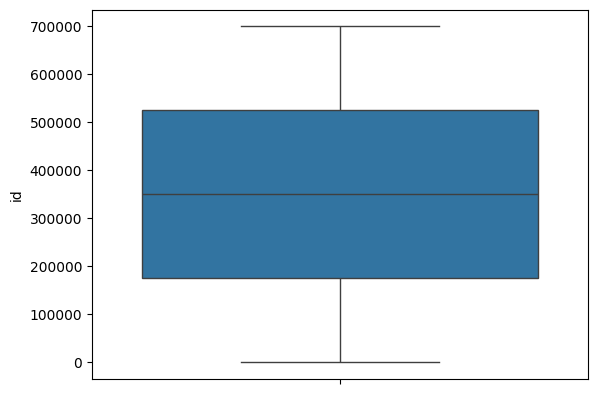

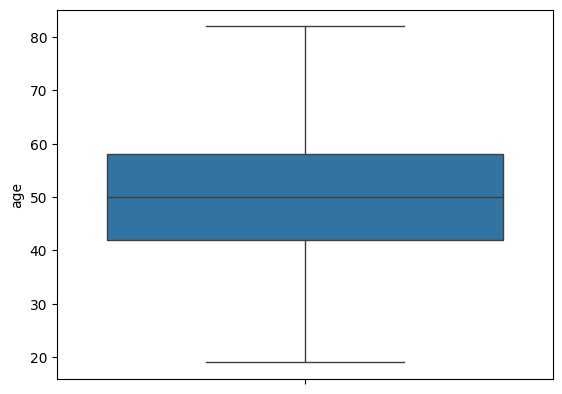

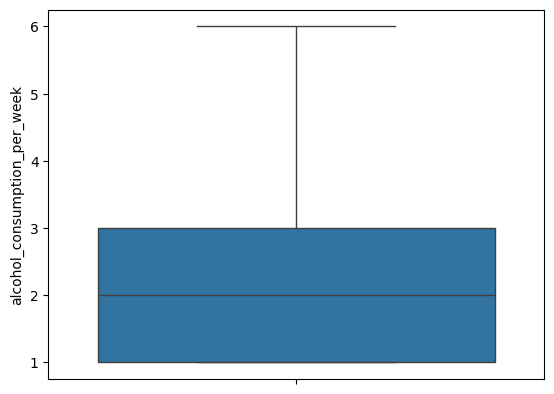

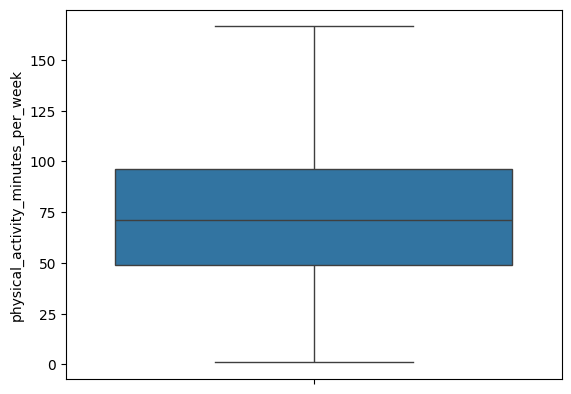

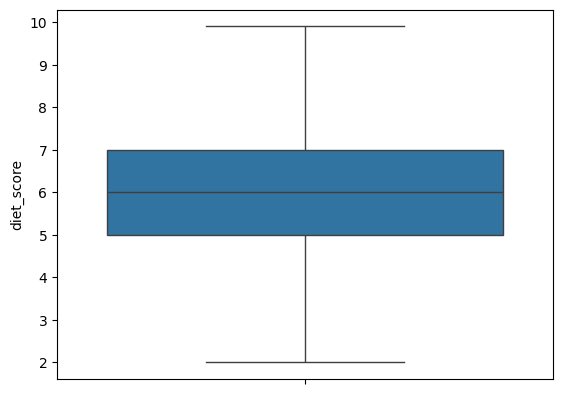

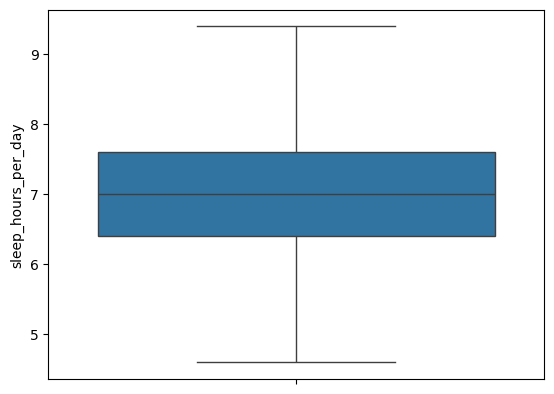

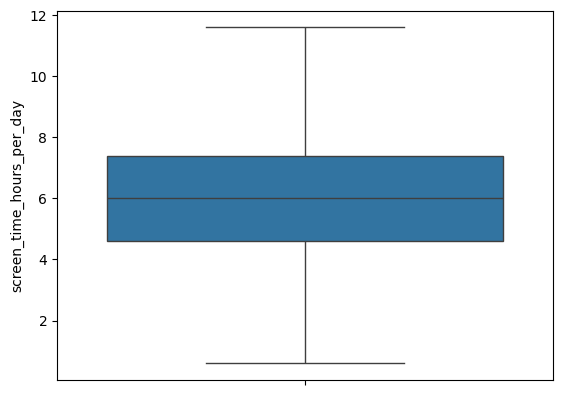

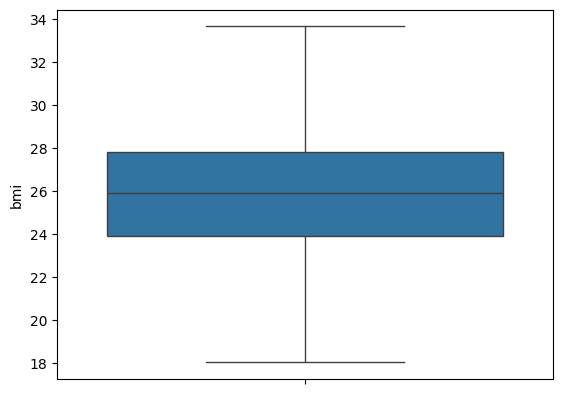

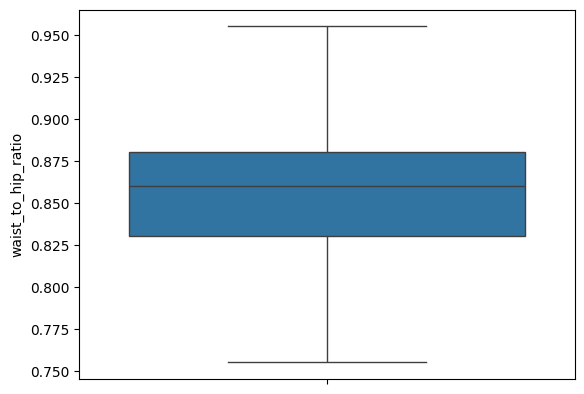

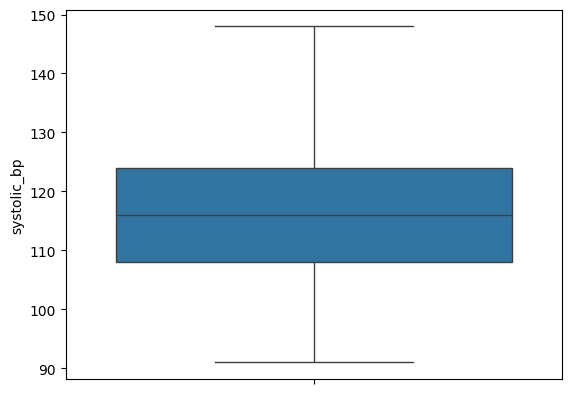

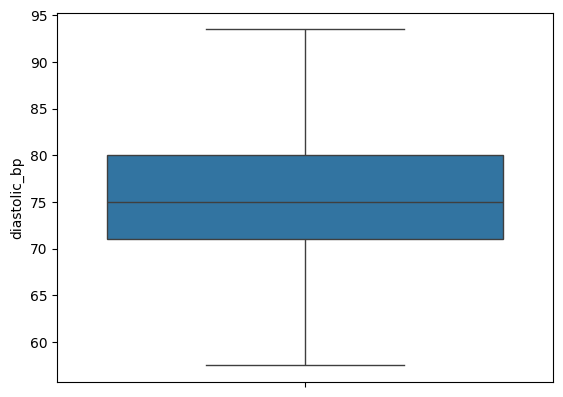

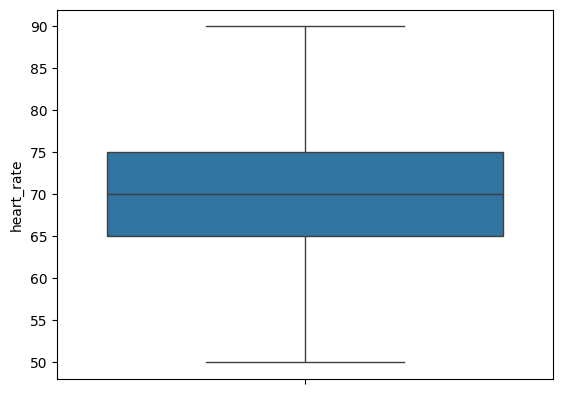

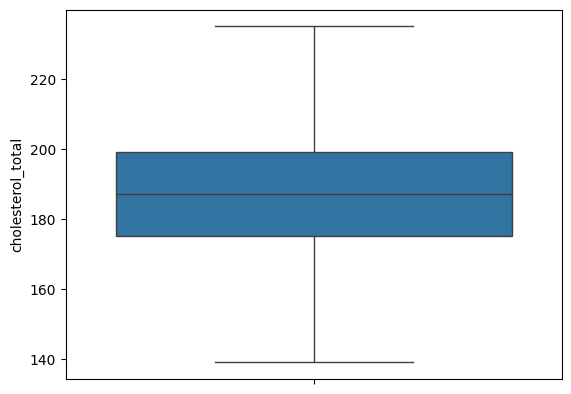

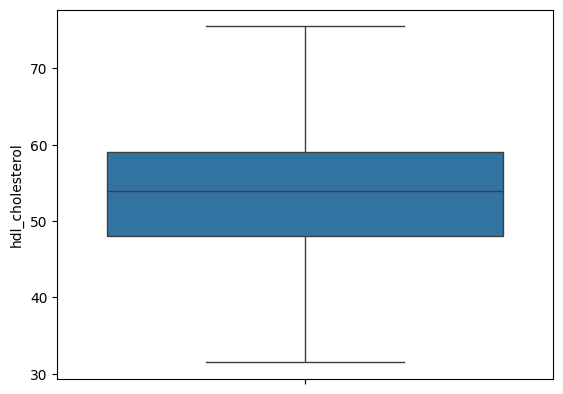

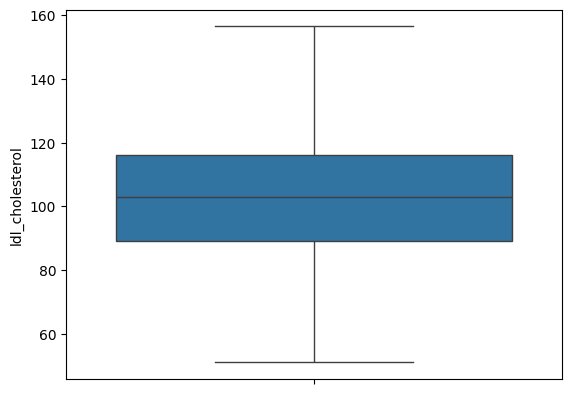

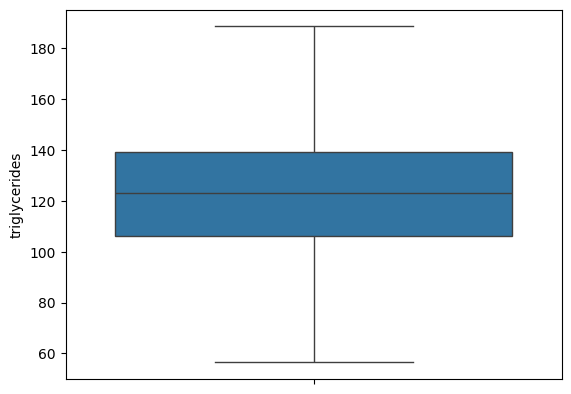

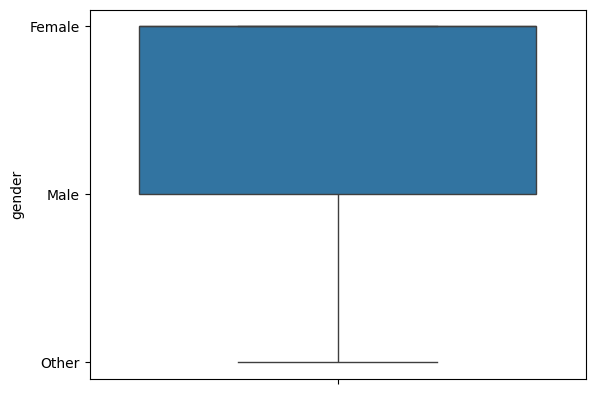

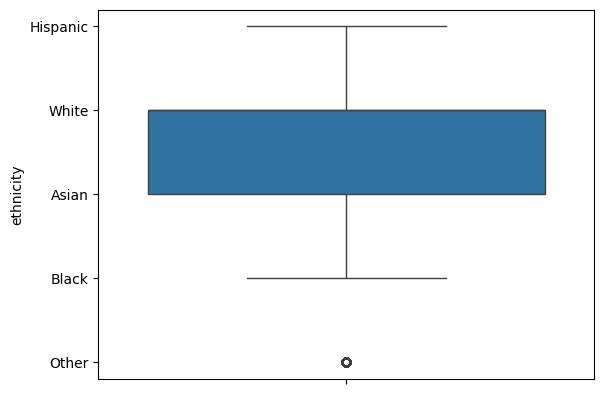

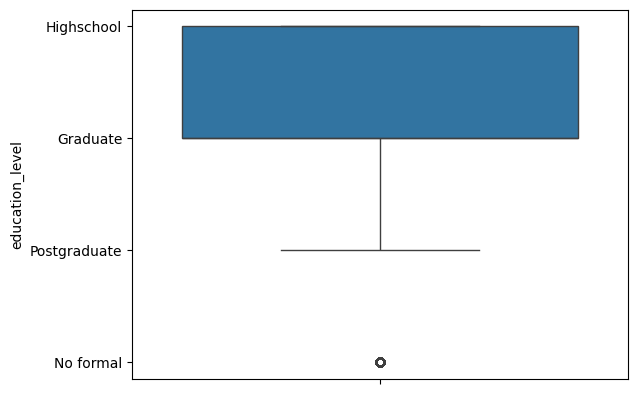

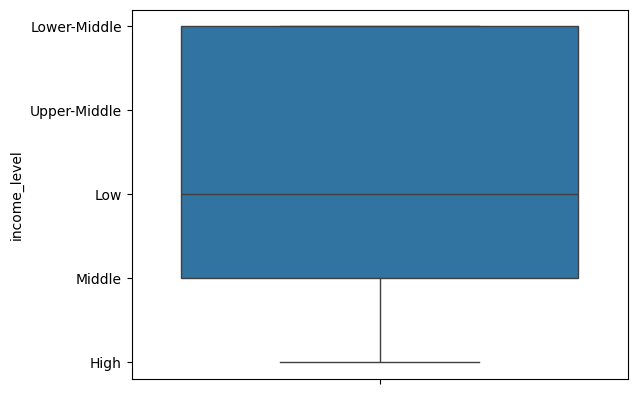

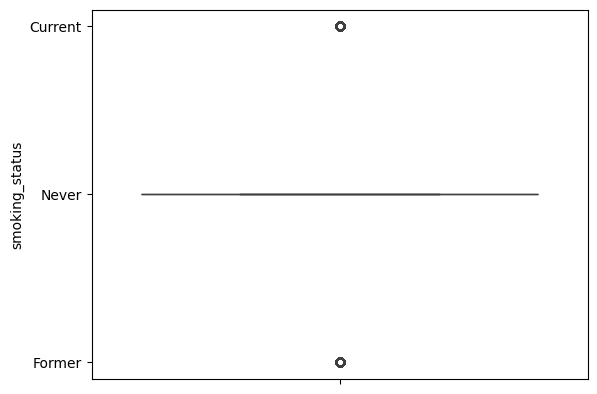

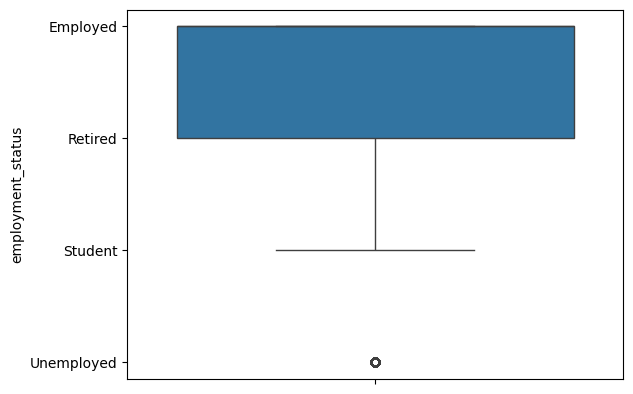

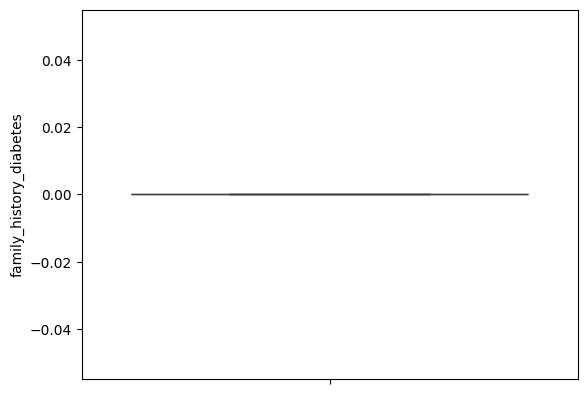

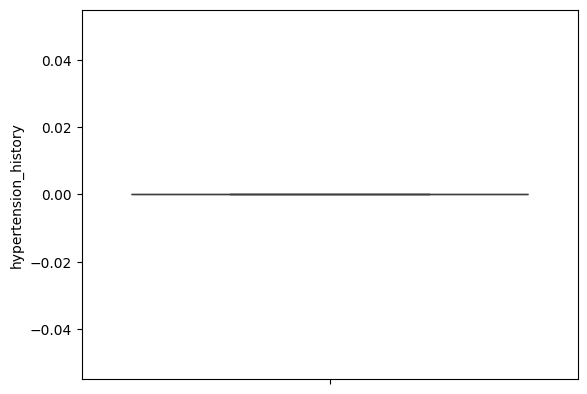

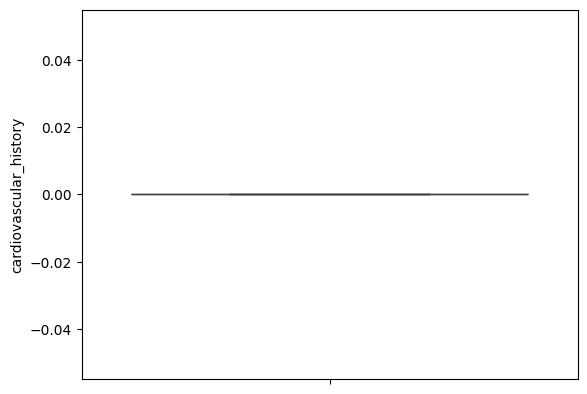

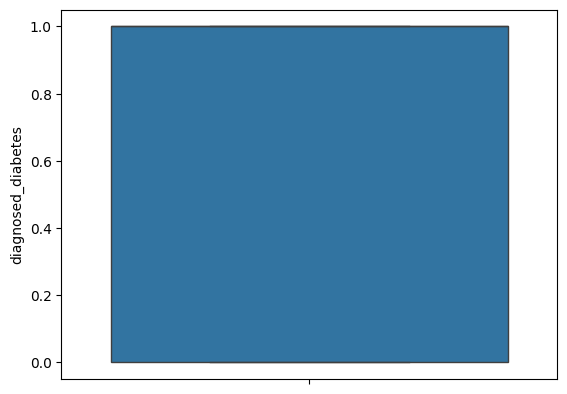

In [19]:
for i in dia.columns:
  sns.boxplot(dia[i])
  plt.show()

Feature Extraction
Creating new features with existing columns

In [20]:
dia["bp_pulse_pressure"] = dia["systolic_bp"] - dia["diastolic_bp"]
dia["map_bp"] = dia["diastolic_bp"] + (dia["bp_pulse_pressure"] / 3)
dia["non_hdl_chol"] = dia["cholesterol_total"] - dia["hdl_cholesterol"]
dia["tg_hdl_ratio"] = dia["triglycerides"] / dia["hdl_cholesterol"]
dia["ldl_hdl_ratio"] = dia["ldl_cholesterol"] / dia["hdl_cholesterol"]
dia["bmi_waist_index"] = dia["bmi"] * dia["waist_to_hip_ratio"]

In [21]:
dia["activity_hours_per_week"] = dia["physical_activity_minutes_per_week"] / 60
dia["sedentary_index"] = dia["screen_time_hours_per_day"] / dia["sleep_hours_per_day"]
dia["sleep_low"] = (dia["sleep_hours_per_day"] < 6).astype(int)
dia["sleep_high"] = (dia["sleep_hours_per_day"] > 8).astype(int)

In [22]:
dia["high_bmi_waist"] = ((dia["bmi"] >= 25) &
                         (dia["waist_to_hip_ratio"] >= 0.9)).astype(int)
dia["any_cvd_htn"] = ((dia["hypertension_history"] == 1) |
                      (dia["cardiovascular_history"] == 1)).astype(int)
dia["age_family_interaction"] = dia["age"] * dia["family_history_diabetes"]
dia["map_x_ldl"] = dia["map_bp"] * dia["ldl_cholesterol"]

In [23]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 40 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  float64
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  float64
 11  heart_rate                

In [24]:
cat_col = [ i for i in dia.columns if dia[i].dtypes == 'object']
cat_col

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'smoking_status',
 'employment_status']

In [25]:
dia[cat_col].nunique()

gender               3
ethnicity            5
education_level      4
income_level         5
smoking_status       3
employment_status    4
dtype: int64

**Changing this categorical columns to numerical using label encoder**

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in cat_col:
    dia[i] = le.fit_transform(dia[i])
    print(dia[i].dtypes)


int64
int64
int64
int64
int64
int64


In [27]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 40 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  float64
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  float64
 11  heart_rate                

In [28]:
from sklearn.model_selection import train_test_split, StratifiedKFold,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score,RocCurveDisplay
X= dia.drop(columns= ['diagnosed_diabetes'])
Y = dia['diagnosed_diabetes']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42, stratify= Y)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        # a bit higher than default 100
    max_depth=10,           # limit depth to avoid overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",  # important if classes are imbalanced
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, Y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


In [30]:
param_grid = {
    "n_estimators": [100, 200],      # was [100, 200, 400]
    "max_depth": [10, None],        # was [None, 5, 10, 20]
    "min_samples_split": [2, 5],    # was [2, 5, 10]
    "min_samples_leaf": [1, 2],     # was [1, 2, 4]
    "max_features": ["sqrt"],       # was ["sqrt", "log2", 0.5]
    "bootstrap": [True],            # was [True, False]
}

cv = StratifiedKFold( n_splits = 3,shuffle=True,random_state = 42)
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid,cv =cv,scoring ='roc_auc',n_jobs =-1,
                          verbose = 2)


In [31]:
grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.7min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.7min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.6min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.7min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.6min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 5.2min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.6min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 5.2min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 5.3min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 5.2min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.6min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 5.0min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=10.7min
[CV] END bootstrap=True, max_depth=10, max_fea

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=10, min_samples_leaf=2,
                                              min_samples_split=5,
                                              n_estimators=200, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [10, None],
                         'max_features': ['sqrt'], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [32]:
print('Best Roc-AUC(CV):', grid_search.best_score_)
print("Best params:")
for k,v in grid_search.best_params_.items():
    print(f'{k}:{v}')
best_model = grid_search.best_estimator_


Best Roc-AUC(CV): 0.6586319398150426
Best params:
bootstrap:True
max_depth:None
max_features:sqrt
min_samples_leaf:2
min_samples_split:2
n_estimators:200


In [33]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]
print("Test ROC-AUC:", roc_auc_score(Y_test, y_proba))
print("\nClassification report:\n", classification_report(Y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred))

Test ROC-AUC: 0.6575503169589754

Classification report:
               precision    recall  f1-score   support

         0.0       0.49      0.59      0.54     52739
         1.0       0.72      0.63      0.67     87261

    accuracy                           0.62    140000
   macro avg       0.61      0.61      0.61    140000
weighted avg       0.63      0.62      0.62    140000


Confusion matrix:
 [[31310 21429]
 [32167 55094]]


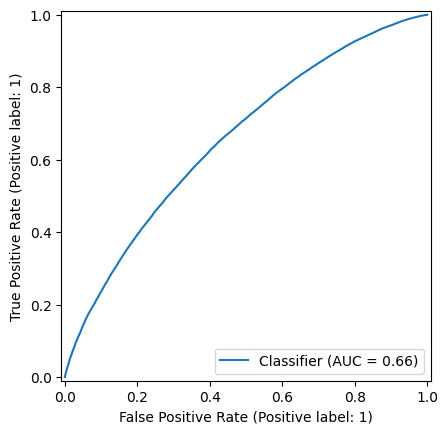

In [34]:
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(Y_test, y_proba)
plt.show()
